# Rakyat Speaks — Final NLP Pipeline
Classical ML sentiment classification: baseline models, hyperparameter tuning experiment, and final model selection.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_sample_weight
import nltk
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = list(stopwords.words('english'))
print('Imports OK')

Imports OK


## 1. Load Data

In [2]:
train_df = pd.read_csv('../data/malaysian_sentiment_labeled.csv')
test_df  = pd.read_csv('../data/NLP_Dataset_preparation/gold_labeled.csv')
print(f'Train: {len(train_df)} rows')
print(f'Test (gold): {len(test_df)} rows')
print(f'\nTrain distribution:\n{train_df["sentiment"].value_counts()}')
print(f'\nTest distribution:\n{test_df["human_label"].value_counts()}')

Train: 7383 rows
Test (gold): 402 rows

Train distribution:
sentiment
neutral     5033
negative    2063
positive     287
Name: count, dtype: int64

Test distribution:
human_label
neutral     241
negative    124
positive     37
Name: count, dtype: int64


## 2. Preprocessing

In [3]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    text = re.sub(r'[*_]{1,2}([^*_]+)[*_]{1,2}', r'\1', text)
    text = re.sub(r'^>.*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'&gt;|&amp;|&lt;|&nbsp;', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'[^\w\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['cleaned'] = train_df['body'].apply(preprocess)
test_df['cleaned']  = test_df['body'].apply(preprocess)
before = len(train_df)
train_df = train_df[train_df['cleaned'].apply(lambda x: len(x.split())) >= 3].reset_index(drop=True)
print(f'Dropped {before - len(train_df)} short rows from train')

X_train_text = train_df['cleaned']
y_train = train_df['sentiment']
X_test_text = test_df['cleaned']
y_test = test_df['human_label']

Dropped 208 short rows from train


## 3. Feature Extraction — TF-IDF and Bag of Words

In [4]:
tfidf = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), max_features=30000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

bow = CountVectorizer(stop_words=stop_words, ngram_range=(1,2), max_features=30000, min_df=2)
X_train_bow = bow.fit_transform(X_train_text)
X_test_bow  = bow.transform(X_test_text)

print(f'TF-IDF shape: {X_train_tfidf.shape}')
print(f'BoW shape:    {X_train_bow.shape}')

TF-IDF shape: (7175, 30000)
BoW shape:    (7175, 30000)


## 4. Train Baseline Models (5 combinations)

In [5]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    sample_w = compute_sample_weight('balanced', y_tr)
    try:
        model.fit(X_tr, y_tr, sample_weight=sample_w)
    except TypeError:
        model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    kappa = cohen_kappa_score(y_te, preds)
    report = classification_report(y_te, preds, target_names=['negative','neutral','positive'], output_dict=True)
    print(f'\n{name}')
    print(f'Accuracy: {acc*100:.1f}%   Kappa: {kappa:.3f}')
    print(classification_report(y_te, preds, target_names=['negative','neutral','positive']))
    return {'name': name, 'model': model, 'acc': acc, 'kappa': kappa, 'preds': preds, 'report': report}

baseline_results = []
nb_tfidf = evaluate('Naive Bayes + TF-IDF', MultinomialNB(), X_train_tfidf, y_train, X_test_tfidf, y_test)
baseline_results.append(nb_tfidf)
nb_bow = evaluate('Naive Bayes + BoW', MultinomialNB(), X_train_bow, y_train, X_test_bow, y_test)
baseline_results.append(nb_bow)
svm_tfidf = evaluate('SVM + TF-IDF', LinearSVC(class_weight='balanced', max_iter=3000), X_train_tfidf, y_train, X_test_tfidf, y_test)
baseline_results.append(svm_tfidf)
svm_bow = evaluate('SVM + BoW', LinearSVC(class_weight='balanced', max_iter=3000), X_train_bow, y_train, X_test_bow, y_test)
baseline_results.append(svm_bow)
logreg_tfidf = evaluate('Logistic Regression + TF-IDF', LogisticRegression(class_weight='balanced', max_iter=3000), X_train_tfidf, y_train, X_test_tfidf, y_test)
baseline_results.append(logreg_tfidf)


Naive Bayes + TF-IDF
Accuracy: 64.2%   Kappa: 0.373
              precision    recall  f1-score   support

    negative       0.56      0.56      0.56       124
     neutral       0.79      0.70      0.74       241
    positive       0.33      0.57      0.42        37

    accuracy                           0.64       402
   macro avg       0.56      0.61      0.57       402
weighted avg       0.67      0.64      0.65       402


Naive Bayes + BoW
Accuracy: 61.2%   Kappa: 0.322
              precision    recall  f1-score   support

    negative       0.50      0.59      0.54       124
     neutral       0.76      0.65      0.70       241
    positive       0.32      0.46      0.38        37

    accuracy                           0.61       402
   macro avg       0.53      0.57      0.54       402
weighted avg       0.64      0.61      0.62       402


SVM + TF-IDF
Accuracy: 67.7%   Kappa: 0.357
              precision    recall  f1-score   support

    negative       0.60      0.51  

## 5. Save FINAL_BEST Models (the 3 winning baseline combinations)
These are the models to use in Streamlit. Hyperparameter tuning (Section 6) was attempted but underperformed these baselines on every metric, so these baseline models remain the final, deployed versions.

In [6]:
FINAL_BEST_DIR = '../models/final_best'
os.makedirs(FINAL_BEST_DIR, exist_ok=True)

with open(f'{FINAL_BEST_DIR}/rakyat_speaks_ml_NB_TFIDF_FINAL_BEST.pkl', 'wb') as f:
    pickle.dump(nb_tfidf['model'], f)
with open(f'{FINAL_BEST_DIR}/rakyat_speaks_ml_NB_TFIDF_FINAL_BEST_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open(f'{FINAL_BEST_DIR}/rakyat_speaks_ml_SVM_BoW_FINAL_BEST.pkl', 'wb') as f:
    pickle.dump(svm_bow['model'], f)
with open(f'{FINAL_BEST_DIR}/rakyat_speaks_ml_SVM_BoW_FINAL_BEST_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow, f)

with open(f'{FINAL_BEST_DIR}/rakyat_speaks_ml_LogReg_TFIDF_FINAL_BEST.pkl', 'wb') as f:
    pickle.dump(logreg_tfidf['model'], f)
with open(f'{FINAL_BEST_DIR}/rakyat_speaks_ml_LogReg_TFIDF_FINAL_BEST_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Saved 3 FINAL_BEST models and their vectorizers to', FINAL_BEST_DIR)

Saved 3 FINAL_BEST models and their vectorizers to ../models/final_best


## 6. Hyperparameter Tuning Experiment
Documented attempt to improve on baseline via GridSearchCV. Result: tuned models underperformed baseline on every metric due to class-distribution mismatch between training data (4% positive) and the gold test set (9% positive). Saved separately, NOT used as final models.

In [7]:
def tune_and_evaluate(name, model, param_grid, vec_configs):
    best_score = -1
    best_pipeline = None
    best_params = None
    for vec_cfg in vec_configs:
        if vec_cfg['analyzer'] == 'char_wb':
            vec = TfidfVectorizer(analyzer='char_wb', ngram_range=vec_cfg['ngram_range'],
                                   min_df=vec_cfg['min_df'], max_features=vec_cfg['max_features'])
        else:
            vec = TfidfVectorizer(stop_words=stop_words, ngram_range=vec_cfg['ngram_range'],
                                   min_df=vec_cfg['min_df'], max_features=vec_cfg['max_features'])
        X_tr = vec.fit_transform(X_train_text)
        sw = compute_sample_weight('balanced', y_train)
        grid = GridSearchCV(model, param_grid, scoring='f1_macro', cv=6, n_jobs=-1)
        try:
            grid.fit(X_tr, y_train, sample_weight=sw)
        except TypeError:
            grid.fit(X_tr, y_train)
        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            best_pipeline = (vec, grid.best_estimator_)
            best_params = {**vec_cfg, **grid.best_params_}
    vec, model = best_pipeline
    X_test_vec = vec.transform(X_test_text)
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    kappa = cohen_kappa_score(y_test, preds)
    report = classification_report(y_test, preds, target_names=['negative','neutral','positive'], output_dict=True)
    print(f'\n{name}')
    print(f'Best params: {best_params}')
    print(f'CV macro-F1: {best_score:.3f}')
    print(f'Test Accuracy: {acc*100:.1f}%   Test Kappa: {kappa:.3f}')
    print(classification_report(y_test, preds, target_names=['negative','neutral','positive']))
    return {'name': name, 'model': model, 'vectorizer': vec, 'acc': acc, 'kappa': kappa,
            'neg_f1': report['negative']['f1-score'], 'neu_f1': report['neutral']['f1-score'],
            'pos_f1': report['positive']['f1-score'], 'best_params': best_params}

vec_configs = [
    {'analyzer': 'word', 'ngram_range': (1,2), 'min_df': 2, 'max_features': 30000},
    {'analyzer': 'word', 'ngram_range': (1,3), 'min_df': 2, 'max_features': 30000},
    {'analyzer': 'word', 'ngram_range': (1,2), 'min_df': 2, 'max_features': 10000},
    {'analyzer': 'word', 'ngram_range': (1,2), 'min_df': 2, 'max_features': 5000},
    {'analyzer': 'char_wb', 'ngram_range': (2,4), 'min_df': 2, 'max_features': 30000},
]

tuned_results = []
tuned_results.append(tune_and_evaluate('Naive Bayes (tuned)', MultinomialNB(),
    {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}, vec_configs))
tuned_results.append(tune_and_evaluate('SVM (tuned)', LinearSVC(max_iter=3000),
    {'C': [0.01, 0.1, 1, 5, 10, 50], 'class_weight': [None, 'balanced']}, vec_configs))
tuned_results.append(tune_and_evaluate('Logistic Regression (tuned)', LogisticRegression(max_iter=3000),
    {'C': [0.01, 0.1, 1, 5, 10, 50], 'class_weight': [None, 'balanced']}, vec_configs))


Naive Bayes (tuned)
Best params: {'analyzer': 'word', 'ngram_range': (1, 3), 'min_df': 2, 'max_features': 30000, 'alpha': 2.0}
CV macro-F1: 0.496
Test Accuracy: 61.4%   Test Kappa: 0.337
              precision    recall  f1-score   support

    negative       0.53      0.51      0.52       124
     neutral       0.77      0.67      0.72       241
    positive       0.30      0.62      0.41        37

    accuracy                           0.61       402
   macro avg       0.54      0.60      0.55       402
weighted avg       0.66      0.61      0.63       402


SVM (tuned)
Best params: {'analyzer': 'char_wb', 'ngram_range': (2, 4), 'min_df': 2, 'max_features': 30000, 'C': 0.1, 'class_weight': None}
CV macro-F1: 0.494
Test Accuracy: 63.4%   Test Kappa: 0.336
              precision    recall  f1-score   support

    negative       0.54      0.56      0.55       124
     neutral       0.74      0.71      0.72       241
    positive       0.35      0.43      0.39        37

    accuracy

## 7. Save Tuned Models (experimental, not used as final)

In [8]:
TUNED_DIR = '../models/experiments_tuned_underperformed'
os.makedirs(TUNED_DIR, exist_ok=True)

tuned_pkl_names = {
    'Naive Bayes (tuned)': 'NB_TFIDF_TUNED',
    'SVM (tuned)': 'SVM_TFIDF_TUNED',
    'Logistic Regression (tuned)': 'LogReg_TFIDF_TUNED',
}
for r in tuned_results:
    base = tuned_pkl_names[r['name']]
    with open(f'{TUNED_DIR}/rakyat_speaks_ml_{base}.pkl', 'wb') as f:
        pickle.dump(r['model'], f)
    with open(f'{TUNED_DIR}/rakyat_speaks_ml_{base}_vectorizer.pkl', 'wb') as f:
        pickle.dump(r['vectorizer'], f)
    print(f'Saved {base} to {TUNED_DIR}')

Saved NB_TFIDF_TUNED to ../models/experiments_tuned_underperformed
Saved SVM_TFIDF_TUNED to ../models/experiments_tuned_underperformed
Saved LogReg_TFIDF_TUNED to ../models/experiments_tuned_underperformed


## 8. Final Comparison Table (all models, baseline and tuned)

In [9]:
os.makedirs('../results', exist_ok=True)
RESULTS_FILE = '../results/model_results.csv'

rows = []
for r in baseline_results:
    rows.append({'model': r['name'], 'status': 'final_best' if r['name'] in
                 ['Naive Bayes + TF-IDF', 'SVM + BoW', 'Logistic Regression + TF-IDF'] else 'baseline_not_selected',
                 'accuracy': r['acc'], 'kappa': r['kappa'],
                 'neg_f1': r['report']['negative']['f1-score'],
                 'neu_f1': r['report']['neutral']['f1-score'],
                 'pos_f1': r['report']['positive']['f1-score']})
for r in tuned_results:
    rows.append({'model': r['name'], 'status': 'tuned_underperformed',
                 'accuracy': r['acc'], 'kappa': r['kappa'],
                 'neg_f1': r['neg_f1'], 'neu_f1': r['neu_f1'], 'pos_f1': r['pos_f1']})

final_df = pd.DataFrame(rows)
final_df.to_csv(RESULTS_FILE, index=False)
print(final_df.to_string(index=False))

                       model                status  accuracy    kappa   neg_f1   neu_f1   pos_f1
        Naive Bayes + TF-IDF            final_best  0.641791 0.372733 0.556452 0.738462 0.415842
           Naive Bayes + BoW baseline_not_selected  0.611940 0.322025 0.542751 0.701124 0.377778
                SVM + TF-IDF baseline_not_selected  0.676617 0.357124 0.550218 0.765957 0.379310
                   SVM + BoW            final_best  0.684080 0.366489 0.556054 0.772467 0.379310
Logistic Regression + TF-IDF            final_best  0.669154 0.364884 0.571429 0.754032 0.380952
         Naive Bayes (tuned)  tuned_underperformed  0.614428 0.337353 0.520661 0.717149 0.407080
                 SVM (tuned)  tuned_underperformed  0.634328 0.335761 0.549801 0.723404 0.385542
 Logistic Regression (tuned)  tuned_underperformed  0.644279 0.342664 0.555985 0.729958 0.394366


## 9. Confusion Matrices (FINAL_BEST models only)

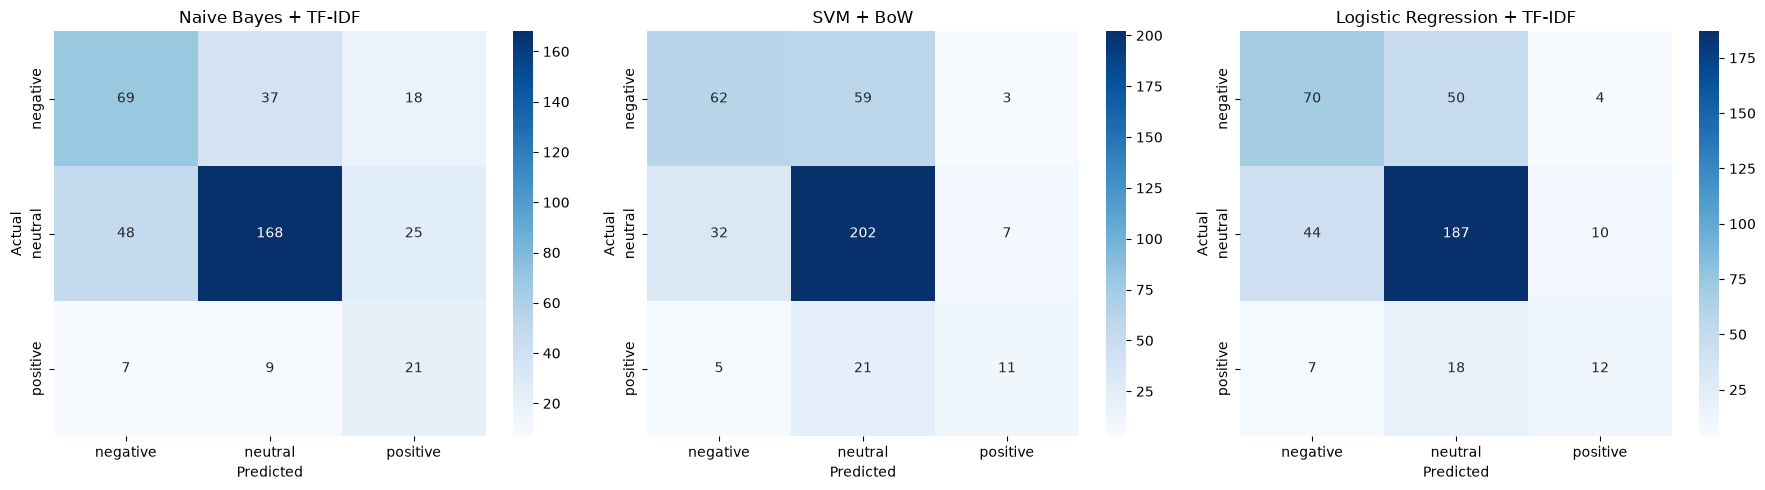

Saved confusion_matrices_final.png


In [10]:
final_three = [nb_tfidf, svm_bow, logreg_tfidf]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['negative', 'neutral', 'positive']
for ax, r in zip(axes, final_three):
    cm = confusion_matrix(y_test, r['preds'], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, xticklabels=labels, yticklabels=labels, cmap='Blues')
    ax.set_title(r['name'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrices_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices_final.png')

## 10. Summary
The three baseline models (Naive Bayes + TF-IDF, SVM + BoW, Logistic Regression + TF-IDF) are the final selected classical ML models, saved under models/final_best/. A GridSearchCV hyperparameter tuning experiment was conducted across multiple n-gram ranges, feature counts, and regularization strengths, but tuned models underperformed baseline on every metric (accuracy, kappa, and F1 across all three classes). This is attributed to a class-distribution mismatch: the training data is 4 percent positive sentiment, while the gold test set is 9 percent positive, so hyperparameters selected via cross-validation on training folds did not transfer well to the differently-distributed test set. The tuning experiment is preserved under models/experiments_tuned_underperformed/ as documented evidence of this finding.